In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px  
import plotly.graph_objects as go 

In [2]:
kp = pd.read_csv("C:/Users/Пользователь/Desktop/jupyter/гп2/kinopoisk_final_data.csv")

In [3]:
ks = pd.read_csv("C:/Users/Пользователь/Downloads/ks_final.csv")

## **Анализ категорий фильмов и данных с кинопоиска**

**Описание признаков данных с кинопоиска:**

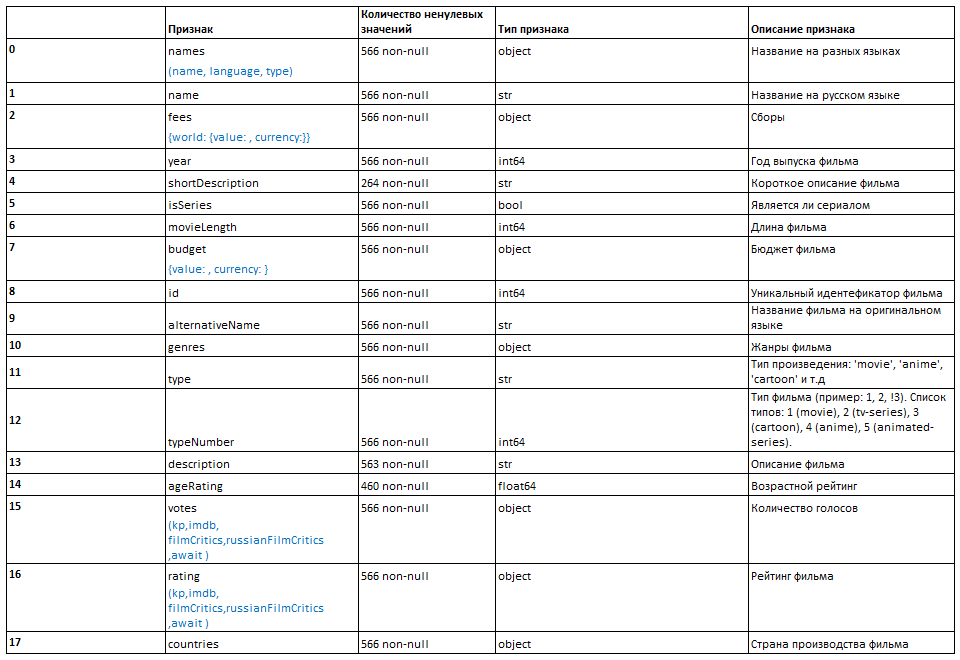

In [4]:
for i in ks['category_slug'].unique():
    print(i)

technology/fabrication tools
technology/robots
technology/camera equipment
technology/gadgets
design/product design
games/video games
technology/hardware
film & video/animation
technology/diy electronics
technology/wearables
games/playing cards
crafts/woodworking
crafts/diy
photography/photobooks
comics/comic books
fashion/accessories
film & video/television
games/gaming hardware
music/world music
crafts/stationery
games/tabletop games
fashion/apparel
fashion/footwear
technology/3d printing
design/toys
technology/sound
technology
art/performance art
crafts/pottery
film & video/narrative film
crafts/printing
crafts
crafts/knitting
comics/graphic novels
music/metal
art/illustration
art/sculpture
food/restaurants
technology/space exploration
comics
art/mixed media
music
film & video/documentary
technology/software
technology/apps
photography
fashion
technology/flight
crafts/weaving
comics/webcomics
theater/musical
film & video/science fiction
film & video/action
film & video/webseries
mus

Отбираем только данные где category_slug = 'film & video/documentary', 'film & video/shorts', 'film & video/narrative film', 'film & video/webseries', 'film & video', 'film & video/animation', 'film & video/comedy', 'film & video/science fiction', 'film & video/drama', 'film & video/horror', 'film & video/movie theaters', 'film & video/fantasy', 'film & video/romance', 'film & video/festivals', 'film & video/experimental', 'film & video/music videos', 'film & video/family', 'film & video/action'

In [5]:
ks_f = ks[ks['category_slug'].isin(['film & video/documentary',
'film & video/shorts',
'film & video/narrative film',
'film & video/webseries',
'film & video',
'film & video/animation',
'film & video/comedy',
'film & video/science fiction',
'film & video/drama',
'film & video/horror',
'film & video/movie theaters',
'film & video/fantasy',
'film & video/romance',
'film & video/festivals',
'film & video/experimental',
'film & video/music videos',
'film & video/family',
'film & video/action'
])]

In [6]:
ks_f['category_name'].unique()

<StringArray>
[      'Animation',  'Narrative Film',     'Documentary', 'Science Fiction',
          'Action',       'Webseries',          'Comedy',    'Film & Video',
          'Shorts',           'Drama',          'Horror',  'Movie Theaters',
         'Romance',         'Fantasy',       'Festivals',    'Experimental',
    'Music Videos',          'Family']
Length: 18, dtype: str

Добавляем новую колонку где будет указан основной жанр фильма

In [7]:
kp['1_genre']  = (kp['genre'].str.split(','))

In [8]:
for i in range(len(kp)):
    kp.loc[i, '1_genre'] = kp.loc[i, '1_genre'][0]

In [9]:
kp = kp[kp['1_genre'].isin(['боевик', 'драма', 'мелодрама',
       'ужасы', 'аниме', 'комедия', 'концерт',
       'документальный', 'фэнтези', 'мультфильм', 'история', 'фантастика',
       'музыка', 'мюзикл', 'семейный',
       'приключения'])]

In [10]:
genre_translation = {
    'боевик': 'Action',
    'драма': 'Drama',
    'мелодрама': 'Romance',
    'ужасы': 'Horror',
    'аниме': 'Animation',  
    'комедия': 'Comedy',
    'концерт': 'Music Videos',  
    'документальный': 'Documentary',
    'фэнтези': 'Fantasy',
    'мультфильм': 'Animation',
    'история': 'Documentary',  
    'фантастика': 'Science Fiction',
    'музыка': 'Music Videos',
    'мюзикл': 'Music Videos',
    'семейный': 'Family',
    'приключения': 'Adventure'  
}

In [12]:
kp['1_genre_eng'] = kp['1_genre'].map(genre_translation)

In [15]:
svod = pd.pivot_table(ks_f , values = ['spotlight',
                                       'staff_pick',
                                       'usd_pledged_per_day',
                                       'percent_funded'] , 
                      index = 'category_name', 
                      aggfunc = {'spotlight' : 'sum', 
                                 'staff_pick' : 'sum',
                                 'usd_pledged_per_day' : 'mean',
                                'percent_funded' : 'mean'})

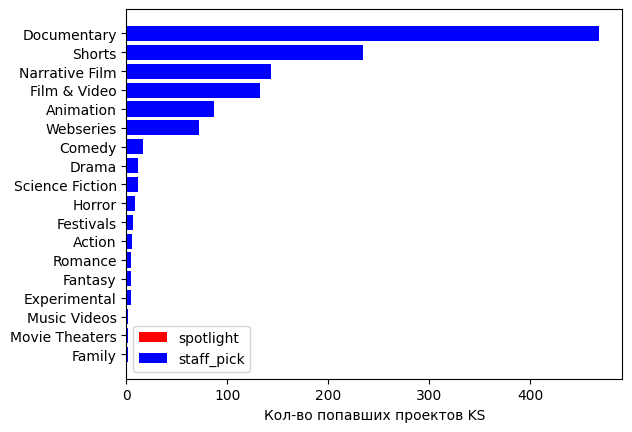

In [16]:
svod = svod.sort_values('spotlight')
plt.barh(svod.index, svod['spotlight'], color = 'red', label = 'spotlight')
plt.barh(svod.index, svod['staff_pick'], color = 'blue',label = 'staff_pick' )
plt.xlabel('Кол-во попавших проектов KS')
plt.legend()
plt.show()

Видим, что чаще всего в spotlight и в отмеченное площадкой попадают документальные,наративные фильмы, а также короткометражки

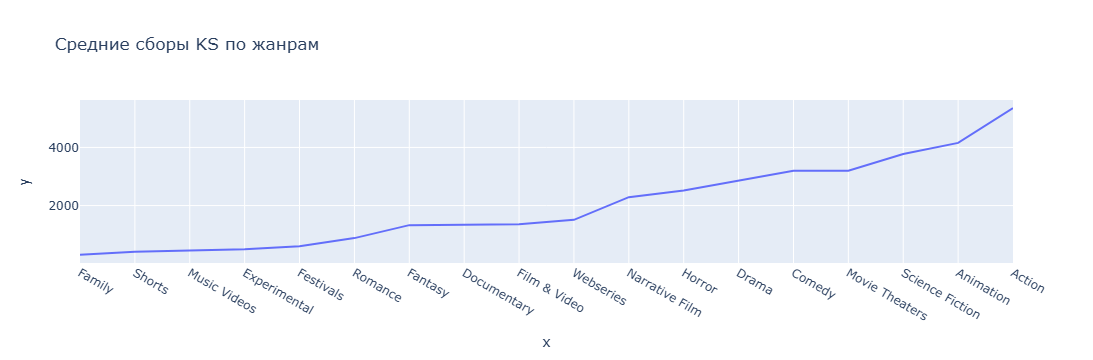

In [18]:
svod = svod.sort_values('usd_pledged_per_day')
fig = px.line(x=svod.index, y=svod['usd_pledged_per_day'], title='Средние сборы KS по жанрам')  
fig.show()

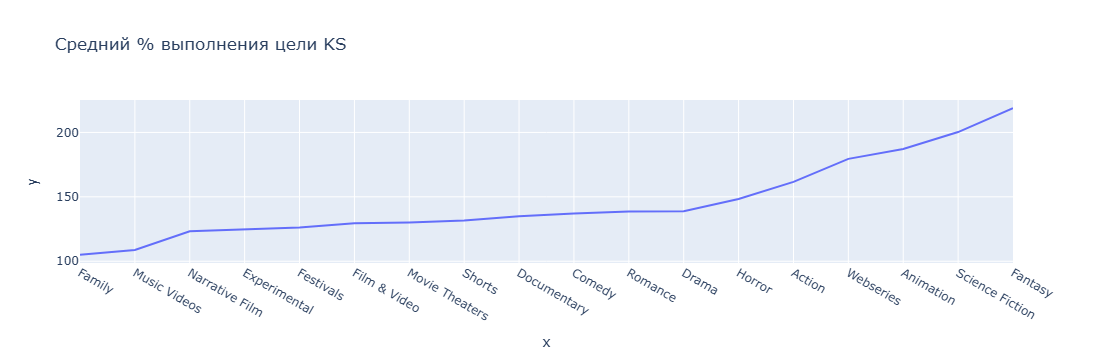

In [19]:
svod = svod.sort_values('percent_funded')
fig = px.line(x=svod.index, y=svod['percent_funded'], title='Средний % выполнения цели KS')  
fig.show()

In [20]:
svod1 = pd.pivot_table(kp , values = 'film_fees' , 
                      index = '1_genre_eng', 
                      aggfunc = {'film_fees' : 'mean'}).sort_values('film_fees')

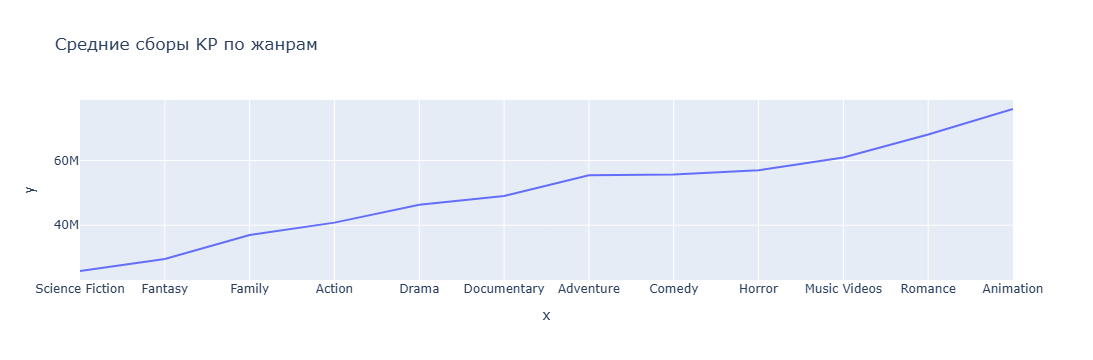

In [21]:
fig = px.line(x=svod1.index, y=svod1['film_fees'], title='Средние сборы KP по жанрам')  
fig.show()

In [22]:
svod3 = pd.pivot_table(kp[kp['year']>2010], values='film_fees', 
                       index='year', 
                       columns='1_genre_eng', 
                       aggfunc='mean').fillna(0)

<Axes: xlabel='1_genre_eng', ylabel='year'>

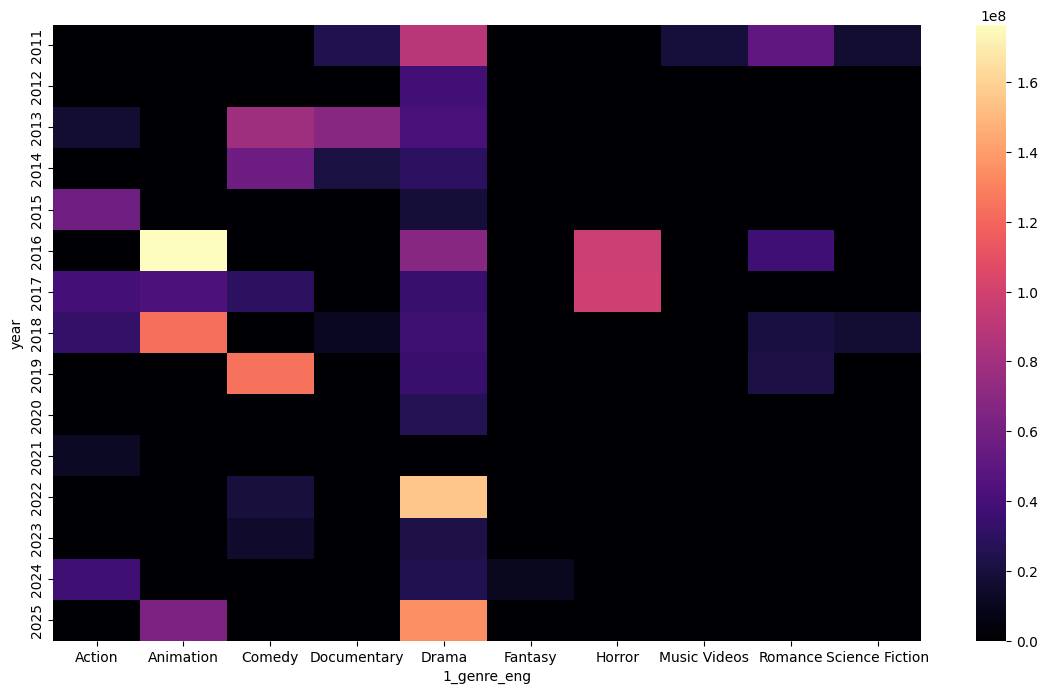

In [23]:
plt.figure(figsize=(14, 8))
sns.heatmap(svod3, linecolor = 'white', cmap = 'magma')

In [24]:
svod4 = pd.pivot_table(kp , values = 'kp_rating' , 
                      index = '1_genre_eng', 
                      aggfunc = {'kp_rating' : 'mean'}).sort_values('kp_rating')

Text(0.5, 0, 'Рейтинг KP')

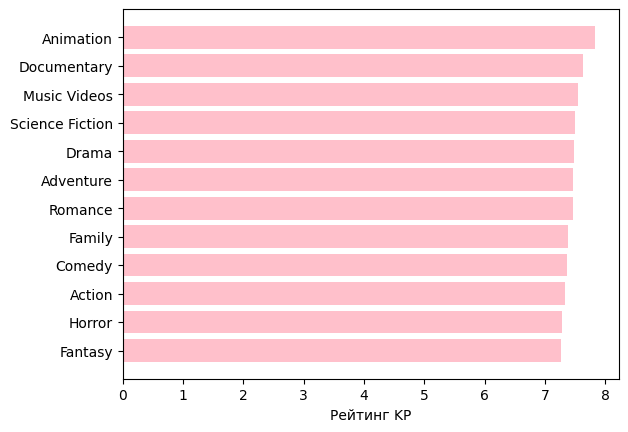

In [25]:
plt.barh( svod4.index, svod4['kp_rating'] , color = 'pink')
plt.xlabel('Рейтинг KP')

**Исходя из анализов можно сделать следующие выводы:**

1. В подборку 'Spotlight' и отобранное платформой чаще всего попадают следующие жанры фильмов: Documentary, Shorts, Narrative film, Animation, Comedy. Также выделяются и Webseries
2. Лучшие сборы и % выполнения цели имеют: Action, Animation, Science Fiction, Movie Theaters, Comedy, Drama, Fantasy, Horror.
Также выделяются и Webseries
3. В целом в киноиндустрии бОльшие сборы имеют: Animation, Romance, Music Videos, Horror, Comedy.
4. c 2011 года в киноиндустрии хорошие сборы имели Drama фильмы, а в 2025 выделились также Animation фильмы
5. Наилучшие рейтинги также у Animation и Documentary фильмов